# Which fifty members lead each of the four segments?

**Week 2, Wednesday. Chapter 2 of 6.** Chapter 1 ranked the whole book; this chapter builds
the list Marketing asked for, one per segment.

> "Give us the top fifty customers by Q2 revenue in each segment."
> The marketing lead, Kalpa Retail

**Who needs the answer.** The marketing lead spends each segment's protect budget on that
segment's own members, and the head of Retail-Plus, the owner of Kalpa's paid membership
tier, wants his best members called before they drift. A list that hands Retail-Plus a few
places and Student none leaves the tier Marketing is worried about mostly unprotected, and a
Retail-Plus member who lapses takes the membership fee and every order after it.

**The questions on the way.**
1. Which ways could the team build one list per segment, and what would each cost?
2. Can GROUP BY return each segment's top fifty?
3. What does numbering the whole book once give each segment?
4. What does PARTITION BY restart, and how many members does each list hold?
5. Does one sorted query per segment pick the same members?

**The metric at stake.** Q2 revenue per member, the booked amount of every Q2 order the
member placed whatever its status, as Monday's suite counted Rs 9,84,00,000 for Q2 (July to
September 2026). Kalpa Retail's four segments are Business (corporate buyers, whose orders
run to lakhs), Retail-Core (everyday shoppers), Retail-Plus (the paid membership tier) and
Student; the segment lives on the customer. The retail dossier, `content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, section 4,
says what the head of Retail-Plus watches.

**What chapter 1 found.** Ranked across the whole book, the fifty members who spent most in
Q2 are 35 Business members, which is every Business buyer, then 11 Retail-Plus and 4
Retail-Core members, and no Student. The 35th member booked Rs 2,25,000 and the 36th, the
first retail member, Rs 21,740, so a single list is a Business list. Ranking members needs a
window function, which numbers rows and keeps every one of them, where GROUP BY collapses
each group to one row.

**A real company with the same question.** Amazon ranks every product it sells by sales and
says that the overall rank "doesn't always indicate how well an item is selling in relation
to similar items", so it also keeps best-seller lists by category and subcategory and shows
an item's rank within its categories on the product page (Amazon's help page on Best
Sellers Rank, checked 1 October 2026). India's JEE Advanced does the same with people: each
category list has its own rank 1, and in 2026 the OBC-NCL rank 1 stood third on the common
list and the GEN-EWS rank 1 sixth (the JEE Advanced 2026 results release of 1 June 2026,
checked 1 October 2026).

**Setup.** The next cell finds the shared helper, `c2kit`, by walking up from this folder
until it reaches `scripts/`, connects to the Kalpa warehouse and reads the named queries in
`../sql/C2_W02_D03_02_each_segment_STUDENT.sql`. Every query below is a block of that file, so what
runs here is exactly what runs from VS Code. If no database answers, the error names the
command that loads the warehouse: `bash .devcontainer/load_warehouse.sh`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import re
from decimal import Decimal
SQL_DIR = kit.data_dir().parent / "sql"

def blocks(stem):
    """Every named block of a .sql file in ../sql/, keyed by the name on its '-- name:' line."""
    text = (SQL_DIR / f"C2_W02_D03_{stem}_STUDENT.sql").read_text(encoding="utf-8")
    parts = re.split(r"^-- name: (\w+)\s*$", text, flags=re.M)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

def num(v):
    """A database number as a Python int or float."""
    if isinstance(v, Decimal):
        return int(v) if v == v.to_integral_value() else float(v)
    return v

def rows(query):
    """Run a query and hand back its rows with every number as a Python number."""
    return [{k: num(v) for k, v in r.items()} for r in kit.sql(query)]

def show(found, caption="", money=(), limit=12):
    """Rows as the kit's table, with the columns named in money set in rupees."""
    if not found:
        kit.table(["result"], [["no rows"]], caption)
        return
    heads = list(found[0])
    def cell(h, v):
        v = num(v)
        if v is None:
            return "NULL"
        if h in money:
            return kit.rupees(v)
        return f"{v:,}" if isinstance(v, int) and abs(v) >= 10000 else str(v)
    body = [[cell(h, r[h]) for h in heads] for r in found[:limit]]
    if len(found) > limit:
        body.append(["..." for _ in heads])
    kit.table(heads, body, caption)

def run(name, caption="", money=(), limit=12, echo=True):
    """Print a named block, run it, show its rows and hand them back."""
    if echo:
        print(Q[name])
    found = rows(Q[name])
    show(found, caption, money, limit)
    return found

def lakh(v):
    """Rupees in lakh, for an axis that has to hold Business and retail members at once."""
    return f"{v / 100000:,.1f} lakh"

Q = blocks("02_each_segment")
print(len(Q), "named queries read from", "C2_W02_D03_02_each_segment_STUDENT.sql;",
      kit.sql("select version()")[0]["version"].split(",")[0])

9 named queries read from C2_W02_D03_02_each_segment_STUDENT.sql; PostgreSQL 16.14 (Ubuntu 16.14-0ubuntu0.24.04.1) on x86_64-pc-linux-gnu


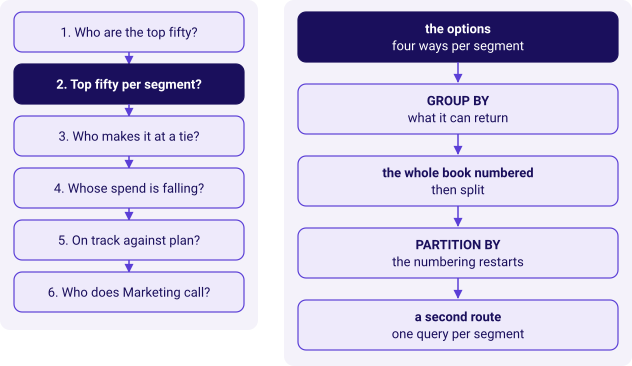

In [2]:
kit.side_by_side(
    kit.ladder(['Who are the top fifty?', 'Top fifty per segment?', 'Who makes it at a tie?', 'Whose spend is falling?', 'On track against plan?', 'Who does Marketing call?'], lit=1, show=False),
    kit.vflow(['the options\nfour ways per segment', 'GROUP BY\nwhat it can return', 'the whole book numbered\nthen split', 'PARTITION BY\nthe numbering restarts', 'a second route\none query per segment'], lit=0, show=False),
)

## The options: which ways could the team build one list per segment, and what would each cost?

| Option | How each segment gets its fifty | Queries to keep | What the database works through | A fifth segment needs |
|---|---|---|---|---|
| A. One sorted query per segment, glued with UNION ALL | each query keeps its own segment and its own LIMIT 50 | 4 | the Q2 orders once per query | a fifth query |
| B. A count of who spent more | a member's place is 1 plus the members of the same segment who booked more | 1 | every pair of members inside a segment | nothing |
| C. A window with PARTITION BY segment | one numbering that starts again at 1 in each segment | 1 | the Q2 orders once, one sort per segment | nothing |
| D. GROUP BY segment with LIMIT 50 | one row per segment, so no member is left to list | 1 | the Q2 orders once | it cannot list members at all |

**Predict before you run.** Option B compares every pair of members inside a segment. How
many comparisons is that on Q2's 227 members?

- a) 227, one per member.
- b) About 1,000.
- c) About 16,600.
- d) 51,529, every member against every member.

option,queries to keep,rows or pairs worked through
A. a query per segment,4,"1,848"
B. count who spent more,1,"16,617"
C. PARTITION BY segment,1,462


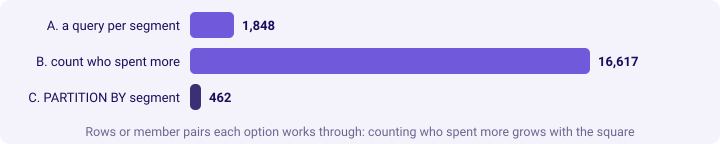

In [3]:
seg = {r["segment"]: r["members_who_bought"] for r in rows(Q["c2_groupby_segment"])}
q2_orders = rows("SELECT count(*) AS n FROM orders WHERE quarter = 'Q2'")[0]["n"]
pairs = sum(n * n for n in seg.values())
sizing = [("A. a query per segment", len(seg), len(seg) * q2_orders),
          ("B. count who spent more", 1, pairs),
          ("C. PARTITION BY segment", 1, q2_orders)]
kit.table(["option", "queries to keep", "rows or pairs worked through"],
          [(o, qn, f"{w:,}") for o, qn, w in sizing],
          caption=f"Sized on Q2: {sum(seg.values())} members in {len(seg)} segments, {q2_orders} orders")
kit.bars([(o, w) for o, _, w in sizing],
         title="Rows or member pairs each option works through: counting who spent more grows with the square",
         lit=(2,))

**What happened.** The answer is c: 16,617 comparisons, 35 squared plus 96 squared plus 76
squared plus 20 squared, because option B sets every member against every member of the
same segment. Option A reads the 462 Q2 orders four times, 1,848 rows, and needs a fifth
query the day a fifth segment appears. Option C reads them once and sorts each segment once.
Option D cannot answer at all, which section 1 shows.

**The best-fit call.** Option C, PARTITION BY segment: one query, one pass, and a new segment
needs no change. **What would change the call:** a database with no window functions, such
as a MySQL server older than version 8.0, the first release line to ship them, which leaves
option A, four sorted queries glued together.

In [4]:
kit.check("four segments bought in Q2", len(seg) == 4)
kit.check("counting who spent more needs 16,617 member pairs", pairs == 16617, f"{pairs:,}")
kit.check("the window reads the orders once, a quarter of option A", sizing[2][2] * 4 == sizing[0][2])

## 1. Can GROUP BY return each segment's top fifty?

The tool every analyst already knows comes first. Two attempts: group by segment, then group
by segment and member with LIMIT 50.

**Predict before you run.** How many rows does `GROUP BY c.segment` return?

- a) 4.
- b) 155, fifty or every buyer per segment.
- c) 200, fifty for each of four segments.
- d) 50.

-- First attempt with GROUP BY: one group per segment. What comes back?
SELECT c.segment,
       count(DISTINCT o.customer_id) AS members_who_bought,
       sum(o.amount)                 AS q2_revenue
FROM   orders o
JOIN   customers c USING (customer_id)
WHERE  o.quarter = 'Q2'
GROUP  BY c.segment
ORDER  BY c.segment;


segment,members_who_bought,q2_revenue
Business,35,"Rs 9,75,84,600"
Retail-Core,96,"Rs 3,66,250"
Retail-Plus,76,"Rs 4,13,380"
Student,20,"Rs 35,770"


-- Second attempt with GROUP BY: one group per member, sorted, LIMIT 50. Counted by segment.
WITH fifty AS (
    SELECT c.segment, o.customer_id, sum(o.amount) AS q2_revenue
    FROM   orders o
    JOIN   customers c USING (customer_id)
    WHERE  o.quarter = 'Q2'
    GROUP  BY c.segment, o.customer_id
    ORDER  BY q2_revenue DESC, o.customer_id
    LIMIT  50
)
SELECT segment, count(*) AS on_the_list
FROM   fifty
GROUP  BY segment
ORDER  BY on_the_list DESC;


segment,on_the_list
Business,35
Retail-Plus,11
Retail-Core,4


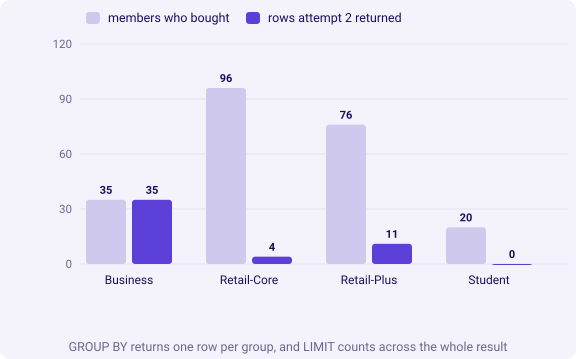

In [5]:
first = run("c2_groupby_segment", "Attempt 1: GROUP BY segment", money=("q2_revenue",))
second = run("c2_groupby_limit", "Attempt 2: GROUP BY segment and member, LIMIT 50, counted by segment")
kit.columns([r["segment"] for r in first],
            [("members who bought", [r["members_who_bought"] for r in first]),
             ("rows attempt 2 returned", [next((s["on_the_list"] for s in second if s["segment"] == r["segment"]), 0)
                                          for r in first])],
            title="GROUP BY returns one row per group, and LIMIT counts across the whole result")

**What happened.** The answer is a. Attempt 1 returns 4 rows, one per segment, because GROUP
BY answers how much per group and keeps nothing below the group. Attempt 2 returns 50 rows,
and they are chapter 1's whole-book list again, 35 Business, 11 Retail-Plus and 4
Retail-Core, because LIMIT counts rows across the whole sorted result and knows nothing of
segments. GROUP BY can say how much each segment booked; it cannot say who leads each one.

In [6]:
kit.check("GROUP BY segment returns four rows", len(first) == 4)
kit.check("LIMIT 50 returns fifty rows across the whole book", sum(r["on_the_list"] for r in second) == 50)
kit.check("LIMIT 50 leaves Student out", "Student" not in {r["segment"] for r in second})

## 2. What does numbering the whole book once give each segment?

Chapter 1 already numbered every member from the biggest down. The quickest per-segment
list reuses that numbering: keep each segment's members whose number is 50 or less.

```sql
row_number() OVER (ORDER BY q2_revenue DESC, customer_id) AS position
...
count(*) FILTER (WHERE position <= 50)   -- per segment
```

**Predict before you run.** How many Retail-Plus members does that give Marketing?

- a) 50, since Retail-Plus has 76 buyers.
- b) 76, every Retail-Plus buyer.
- c) 11.
- d) 0.

-- The hurried per-segment list: number the whole book once, then keep each segment's members whose
-- number is 50 or less.
WITH q2_spend AS (
    SELECT c.segment, o.customer_id, sum(o.amount) AS q2_revenue
    FROM   orders o
    JOIN   customers c USING (customer_id)
    WHERE  o.quarter = 'Q2'
    GROUP  BY c.segment, o.customer_id
),
ranked AS (
    SELECT segment, customer_id, q2_revenue,
           row_number() OVER (ORDER BY q2_revenue DESC, customer_id) AS position
    FROM   q2_spend
)
SELECT segment,
       count(*) FILTER (WHERE position <= 50) AS on_the_segment_list,
       count(*)                               AS members_who_bought
FROM   ranked
GROUP  BY segment
ORDER  BY segment;


segment,on_the_segment_list,members_who_bought
Business,35,35
Retail-Core,4,96
Retail-Plus,11,76
Student,0,20


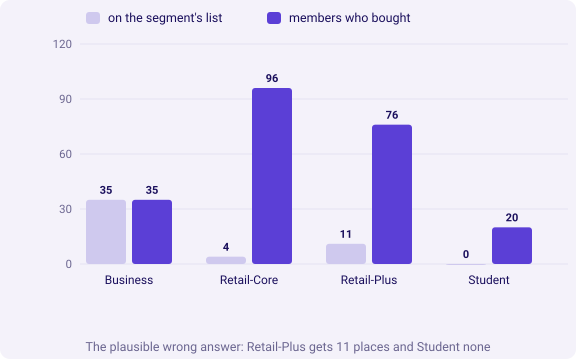

In [7]:
split = run("c2_whole_table_split", "The whole book numbered once, then split by segment")
kit.columns([r["segment"] for r in split],
            [("on the segment's list", [r["on_the_segment_list"] for r in split]),
             ("members who bought", [r["members_who_bought"] for r in split])],
            title="The plausible wrong answer: Retail-Plus gets 11 places and Student none")

**The plausible wrong answer.** Business 35, Retail-Core 4, Retail-Plus 11 and Student 0,
sent as "the top fifty in each segment". The answer to the prediction is c.

**Why it is wrong.** The number came from one ranking of the whole book, where every
Business buyer stands above every retail member, so each retail segment only keeps the
members who also made the whole book's top fifty. Marketing would protect 11 Retail-Plus
members, the tier it is worried about, and tell the Student team it has nobody worth a
call.

**The check that exposes it.** Each segment's list should hold fifty members, or every buyer
where the segment has fewer than fifty. Set the count beside the smaller of 50 and the
segment's buyers: Retail-Plus has 76 buyers and gets 11.

In [8]:
short = [r["segment"] for r in split if r["on_the_segment_list"] != min(50, r["members_who_bought"])]
kit.check("the check flags the segments whose list is short", set(short) == {"Retail-Core", "Retail-Plus", "Student"},
          ", ".join(short))
kit.check("only Business looks right, because all its buyers rank above every retail member",
          [r["segment"] for r in split if r["segment"] not in short] == ["Business"])

## 3. What does PARTITION BY restart, and how many members does each list hold?

**The fix.** PARTITION BY segment inside the window's brackets starts the numbering again at
1 in every segment, so each member's place is a place among its own segment.

```sql
row_number() OVER (PARTITION BY segment
                   ORDER BY q2_revenue DESC, customer_id) AS position
```

**Predict before you run.** How many members do the four lists hold together?

- a) 200, fifty in each segment.
- b) 155.
- c) 50.
- d) 227, every member who bought.

-- The per-segment list: PARTITION BY segment restarts the numbering at 1 inside every segment.
WITH q2_spend AS (
    SELECT c.segment, o.customer_id, sum(o.amount) AS q2_revenue
    FROM   orders o
    JOIN   customers c USING (customer_id)
    WHERE  o.quarter = 'Q2'
    GROUP  BY c.segment, o.customer_id
),
ranked AS (
    SELECT segment, customer_id, q2_revenue,
           row_number() OVER (PARTITION BY segment
                              ORDER BY q2_revenue DESC, customer_id) AS position
    FROM   q2_spend
)
SELECT segment,
       count(*) FILTER (WHERE position <= 50) AS on_the_segment_list,
       count(*)                               AS members_who_bought
FROM   ranked
GROUP  BY segment
ORDER  BY segment;


segment,on_the_segment_list,members_who_bought
Business,35,35
Retail-Core,50,96
Retail-Plus,50,76
Student,20,20


segment,position,customer_id,q2_revenue
Retail-Core,1,C-0010,"Rs 13,910"
Retail-Core,2,C-0040,"Rs 13,550"
Retail-Core,3,C-0041,"Rs 12,460"
Retail-Plus,1,C-0170,"Rs 21,740"
Retail-Plus,2,C-0167,"Rs 14,600"
Retail-Plus,3,C-0160,"Rs 13,700"
Student,1,C-0319,"Rs 5,710"
Student,2,C-0314,"Rs 3,380"
Student,3,C-0320,"Rs 2,630"


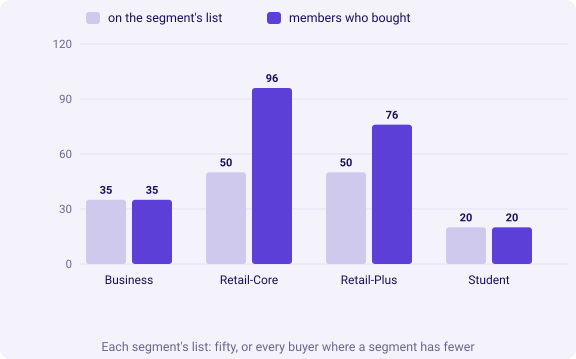

In [9]:
fixed = run("c2_partitioned", "PARTITION BY segment: the numbering restarts in each segment")
run("c2_first_three", "The first three places in each consumer segment", money=("q2_revenue",), echo=False)
kit.columns([r["segment"] for r in fixed],
            [("on the segment's list", [r["on_the_segment_list"] for r in fixed]),
             ("members who bought", [r["members_who_bought"] for r in fixed])],
            title="Each segment's list: fifty, or every buyer where a segment has fewer")

**What happened.** The answer is b: 155 members, Business 35, Retail-Core 50, Retail-Plus 50
and Student 20. Fifty is a cap: Business and Student have fewer than fifty Q2 buyers, so
their lists hold every buyer. The places restart at 1 in each segment, so Retail-Core's
first member, C-0010 on Rs 13,910, and Retail-Plus's, C-0170 on Rs 21,740, both stand at
place 1. The fix moves Retail-Plus from 11 places to 50 and Student from none to 20.

Writing the place straight into WHERE is the first thing most people try, and Postgres
refuses it. Run the next cell, read the last line of the error, and give it two minutes.

In [10]:
with kit.expect_error() as err:
    kit.sql(Q["c2_where_error"])
kit.check("the database refuses a window function inside WHERE", err.name is not None, err.name)

WHERE decides which rows exist before any window is computed, so the place does not exist
yet when WHERE runs. The fix is the shape this chapter already uses: compute the place in a
named step, then filter on it in the query outside. Monday's drawing of the order a query
runs in shows why: FROM, WHERE and GROUP BY come before SELECT, where the window lives.

In [11]:
got = {r["segment"]: r["on_the_segment_list"] for r in fixed}
kit.check("the four lists hold 155 members", sum(got.values()) == 155, str(got))
kit.check("every list holds fifty or every buyer",
          all(r["on_the_segment_list"] == min(50, r["members_who_bought"]) for r in fixed))
kit.check("Retail-Plus goes from 11 places to 50", got["Retail-Plus"] == 50)

## A second route: does one sorted query per segment pick the same members?

Option A, with no window at all: four queries, one per segment, each sorting its own
members by Q2 revenue and then by id and keeping fifty, glued together with UNION ALL. Each
piece sits in brackets so that its ORDER BY and LIMIT apply to it alone. A slip in the
window's PARTITION BY could not move this list, since the two share no window.

**Predict before you run.** Will the four queries return the window's 155 members?

- a) Yes, the same 155 members.
- b) No, 200 rows, fifty from each query.
- c) No, since UNION ALL sorts the result again.
- d) Only the Business and Student members.

In [12]:
union = rows(Q["c2_union"])
window = rows(Q["c2_window_ids"])
by_route = {}
for name, found in (("UNION ALL", union), ("window", window)):
    for r in found:
        by_route.setdefault(r["segment"], {}).setdefault(name, 0)
        by_route[r["segment"]][name] += 1
kit.table(["segment", "four queries, UNION ALL", "one window"],
          [(s, by_route[s].get("UNION ALL", 0), by_route[s].get("window", 0)) for s in sorted(by_route)],
          caption="Two routes, the same lists")
kit.check("the four queries return 155 rows", len(union) == 155)
kit.check("the two routes name the same members in every segment",
          {(r["segment"], r["customer_id"]) for r in union} == {(r["segment"], r["customer_id"]) for r in window})

segment,"four queries, UNION ALL",one window
Business,35,35
Retail-Core,50,50
Retail-Plus,50,50
Student,20,20


**What happened.** The answer is a: 155 rows and the same members in every segment. LIMIT
keeps at most fifty, so the Business and Student queries return all their buyers, 35 and
20. The four queries do the job on this warehouse and become four places to edit when the
segments change, which is why they are the check and the window is the answer.

> **Kavya's review.** Read the ask's last words again before you rank. "In each segment"
> is a PARTITION BY, and each segment's list holds fifty members or every buyer, whichever
> is fewer: count it before it leaves the team.

### In the interview: GROUP BY or a window for a top N per group, and why not WHERE?

**[S] Top three per group: GROUP BY or a window, and why?** A window. GROUP BY collapses
each group to one row, so it can report the group's total but cannot say which rows lead
it, and LIMIT counts across the whole result. A window with PARTITION BY the group numbers
the rows inside each group and keeps them all; a named step computes the place and the
outer query keeps places 1 to 3.

**[F] Why can a window function not sit inside WHERE, and what do you do instead?** WHERE
filters rows before the window is computed, so the place does not exist yet when WHERE runs;
Postgres stops with "window functions are not allowed in WHERE". You compute the place in a
CTE or a subquery and filter on it outside.

### Depth: how much of each segment's Q2 revenue does its list carry?

A list of fifty in a segment of 96 buyers can still carry most of the segment's rupees,
because spend concentrates at the top. The share says how much revenue the protect budget
covers.

segment,list_revenue,segment_revenue
Business,"Rs 9,75,84,600","Rs 9,75,84,600"
Retail-Core,"Rs 2,78,740","Rs 3,66,250"
Retail-Plus,"Rs 3,53,430","Rs 4,13,380"
Student,"Rs 35,770","Rs 35,770"


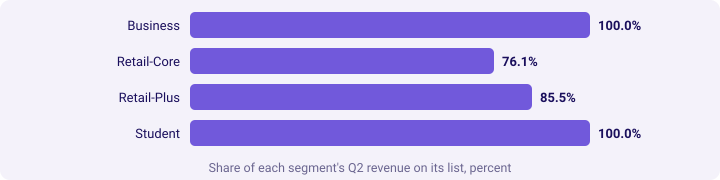

In [13]:
carried = run("c2_list_revenue", "Each list's Q2 revenue against its segment's", money=("list_revenue", "segment_revenue"),
              echo=False)
kit.bars([(r["segment"], round(100 * r["list_revenue"] / r["segment_revenue"], 1)) for r in carried],
         title="Share of each segment's Q2 revenue on its list, percent", fmt=lambda v: f"{v:.1f}%")
kit.check("Business and Student lists carry their whole segment",
          all(r["list_revenue"] == r["segment_revenue"] for r in carried if r["segment"] in ("Business", "Student")))

Retail-Core's fifty carry 76.1 percent of the segment's Q2 revenue and Retail-Plus's fifty
carry 85.5 percent, so half the buyers hold three quarters or more of the rupees in both.

## What did this chapter answer?

1. **Which way, at what cost?** PARTITION BY segment: one query reading the 462 Q2 orders
   once, where four glued queries read them four times and counting who spent more works
   through 16,617 member pairs.
2. **Can GROUP BY do it?** No: it returns 4 rows, one per segment, and LIMIT 50 across the
   book returns chapter 1's list again.
3. **What does the whole book's numbering give each segment?** Business 35, Retail-Core 4,
   Retail-Plus 11 and Student 0; the check is fifty or every buyer per segment.
4. **What does PARTITION BY restart?** The numbering, at 1 in every segment: 155 members,
   Business 35, Retail-Core 50, Retail-Plus 50 and Student 20.
5. **Do four sorted queries agree?** Yes, member for member in every segment.

Each list was cut at fifty by `row_number()`, with the customer id deciding any two members
who booked the same. Chapter 3 asks the head of Retail-Plus's question: when two members
spent the same at the line, who makes the list?

In [14]:
kit.check_summary()